In [447]:
from mypy import *

## 超参数

In [448]:
expo_time = r'800 ms'
power = r'5 $\rm \mu W$'
title = r'{}: {} (曝光时间: ' + expo_time + r'; 激光功率: ' + power + ')'

In [449]:
dir_spade = './spade/2/s2_{}.tif'

spade.point_1 = (52, 48)
spade.point_2 = (52, 198)

spade.characteristic_width = 96 / dmd.pixel_size

In [450]:
dir_di = './di/2/s2_{}.tif'

di.zero_point = 44
di.pixel_size = 2 * qcmos.pixel_size / dmd.pixel_size

In [451]:
samples = 500

In [452]:
matplotlib_parameter.figsize(16, 4)

## SPADE

In [453]:
spade_s = []
p1 = []
p2 = []

for i in range(samples):
    img = imread(dir_spade.format(i+1))
    spade_s.append(spade.estimator(img, mode='+-'))
    p1.append(spade.photon_number(img)[0])
    p2.append(spade.photon_number(img)[1])

spade_s = np.array(spade_s)
p1 = np.array(p1)
p2 = np.array(p2)

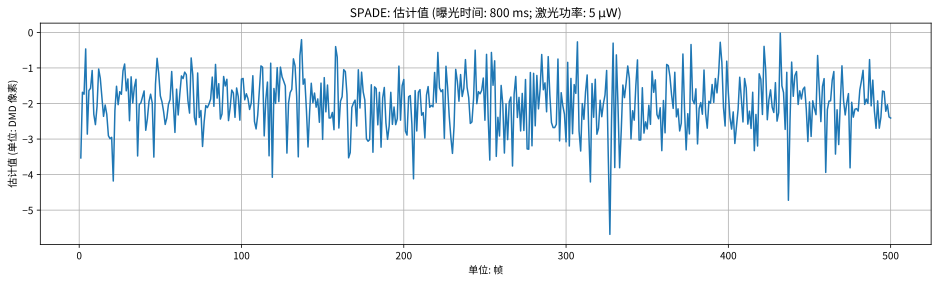

In [454]:
plot((1, samples), spade_s,
     xlabel='单位: 帧', ylabel='估计值 (单位: DMD 像素)', title=title.format('SPADE', '估计值'), 
     save='spade_s.svg')

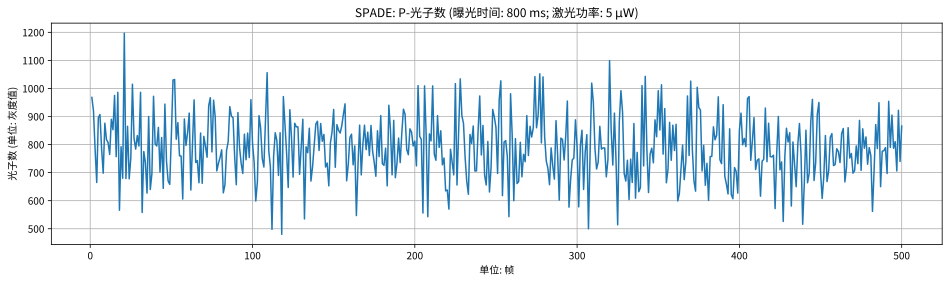

In [455]:
plot((1, samples), p1,
     xlabel='单位: 帧', ylabel='光子数 (单位: 灰度值)', title=title.format('SPADE', 'P-光子数'), 
     save='spade_p-_n.svg')

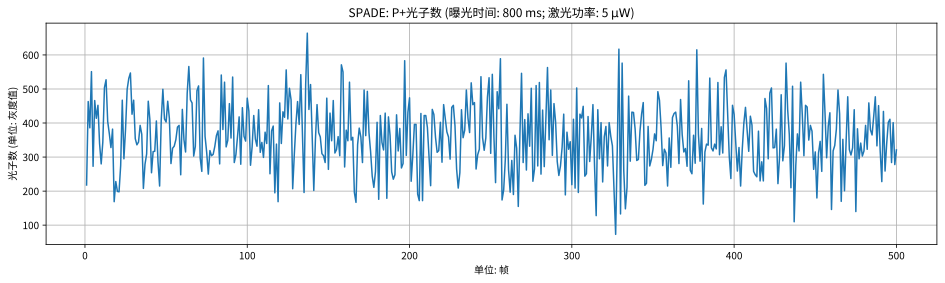

In [456]:
plot((1, samples), p2,
     xlabel='单位: 帧', ylabel='光子数 (单位: 灰度值)', title=title.format('SPADE', 'P+光子数'), 
     save='spade_p+_n.svg')

In [457]:
print('SPADE: ')

spade_mean = spade_s.mean()
print('均值: ' + str(spade_mean))

spade_var = spade_s.var()
print('方差: ' + str(spade_var))

spade_n = (p1+p2).sum()
print('光子数: ' + str(spade_n))

spade_n_var = spade_var * spade_n
print('光子数*方差: ' + str(spade_n_var))

SPADE: 
均值: -1.9909722647474857
方差: 0.6129279414174836
光子数: 573264.0
光子数*方差: 351369.52340875234


## DI

In [458]:
di_s = []
n = []
for i in range(samples):
    img = imread(dir_di.format(i+1))
    di_s.append(di.estimator(img))
    n.append(di.photon_number(img))

di_s = np.array(di_s)
n = np.array(n)

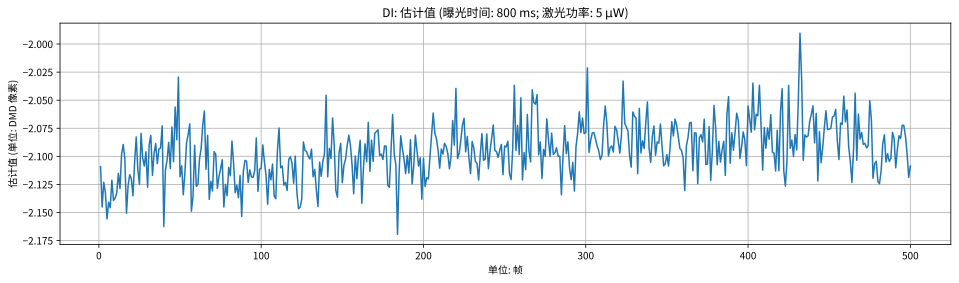

In [459]:
plot((1, samples), di_s, 
     xlabel='单位: 帧', ylabel='估计值 (单位: DMD 像素)', title=title.format('DI', '估计值'), 
     save='di_s.svg')

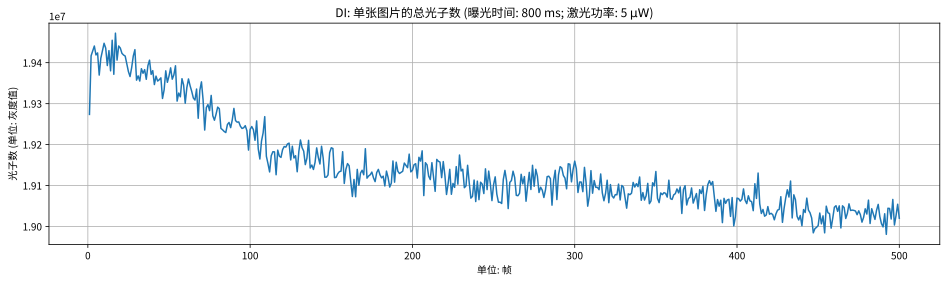

In [460]:
plot((1, samples), n, 
     xlabel='单位: 帧', ylabel='光子数 (单位: 灰度值)', title=title.format('DI', '单张图片的总光子数'), 
     save='di_n.svg')

In [461]:
print('DI: ')

di_mean = di_s.mean()
print('均值: ' + str(di_mean))

di_var = di_s.var()
print('方差: ' + str(di_var))

di_n = n.sum()
print('光子数: ' + str(di_n))

di_n_var = di_var * di_n
print('光子数*方差: ' + str(di_n_var))

DI: 
均值: -2.0953086525614792
方差: 0.0005901136626052023
光子数: 9572790323.0
光子数*方差: 5649034.358857168


## 数据汇总

In [462]:
from IPython.display import Math

def x(num1, num2):
    return '{' + str(num1) + r'\times' + str(num2) + '}'

tex_var = r'\frac{{\rm Var}[s_{_{\rm SPADE}}]}{{{\rm Var}[s_{_{\rm DI}}]}}=\frac'
tex_nvar = r'\frac{N_{_{\rm SPADE}}\times{\rm Var}[s_{_{\rm SPADE}}]}{{N_{_{\rm DI}}\times{\rm Var}[s_{_{\rm DI}}]}}=\frac'

tex_var = tex_var + '{' + str(spade_var) + '}' + '{' + str(di_var) + '}' + '=' + str(spade_var / di_var)
tex_nvar = tex_nvar + x(spade_n, spade_var) + x(di_n, di_var) + '=' + str(spade_n_var / di_n_var)

In [463]:
Math(tex_var)

<IPython.core.display.Math object>

In [464]:
Math(tex_nvar)

<IPython.core.display.Math object>

## 自动生成实验报告模版

In [465]:
import time, os

m, d = time.localtime()[1], time.localtime()[2]

if not os.path.exists('./{}.{}实验报告.md/'.format(m, d)):
    f = open('./{}.{}实验报告.md'.format(m, d), 'w')
    f.write('# {}.{} 实验报告\n'.format(m, d))
    f.write('## 前言\n')
    f.write('**激光功率: {}**\n'.format(power))
    f.write('**曝光时间: {}**\n'.format(expo_time))
    f.write('## 实验结果\n')
    f.write('**方差比值:**\n')
    f.write('\n $$ \n' + tex_var + '\n $$ \n')
    f.write('\n $$ \n' + tex_nvar + '\n $$ \n')
    f.write('**数据图:**\n')
    for line in ['![spade_s](./spade_s.svg)', '![spade_p-_n](./spade_p-_n.svg)', '![spade_p+_n](./spade_p+_n.svg)', 
                '![di_s](./di_s.svg)', '![di_n](./di_n.svg)']:
        f.write(line + '\n')
    f.close()